In [6]:
import os
import sys
import json
import numpy as np
sys.path.append('D:/my_project/my_tool/ppg_noise_reject/utils')
TRAIN_PATH = "J:/My Drive/data_set_ppg_reject4/train"
VAL_PATH = "J:/My Drive/data_set_ppg_reject4/validate"
TEST_PATH = "J:/My Drive/data_set_ppg_reject4/test"
BACK_UP = "J:/My Drive/backup/"
from template_gen import temp_find
import matplotlib.pyplot as plt

KS statistic: 0.06289051541659228
p-value: 0.0006986707016374311
Wasserstein Distance: 1.7297817243798034e-06
Anderson-Darling statistic: 4.2358
------------------------------
Mức ý nghĩa (%) | Giá trị tới hạn
            25% | 0.3250
            10% | 1.2260
             5% | 1.9610
           2.5% | 2.7180
             1% | 3.7520
           0.5% | 4.5920
           0.1% | 6.5460
------------------------------
Kết luận: Hai phân phối CÓ SỰ KHÁC BIỆT (Độ tin cậy 99%)
Anderson_ksampResult(statistic=np.float64(4.235774768806412), critical_values=array([0.325, 1.226, 1.961, 2.718, 3.752, 4.592, 6.546]), pvalue=0.006592091737814087)


C:\Users\phank\AppData\Local\Temp\ipykernel_10980\1452268143.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


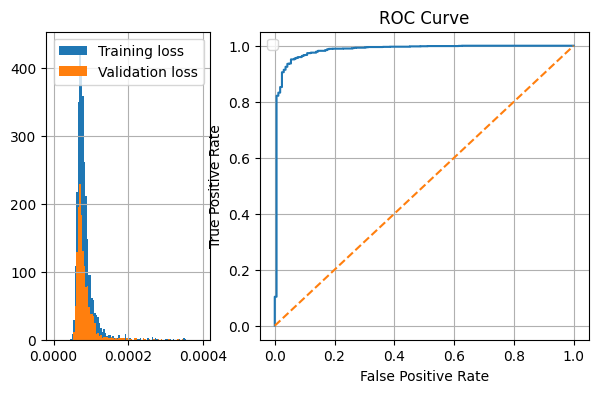

In [45]:
from scipy import stats
from scipy.stats import ks_2samp
from scipy.stats import wasserstein_distance

#Loss sketch + AUC
def check_similarity_anderson(data1, data2):
    # Thực hiện kiểm định Anderson-Darling cho 2 mẫu
    result = stats.anderson_ksamp([data1, data2])
    
    print(f"Anderson-Darling statistic: {result.statistic:.4f}")
    
    # Các ngưỡng giá trị tới hạn (Critical values) tương ứng với các mức ý nghĩa
    # [25%, 10%, 5%, 2.5%, 1%, 0.5%, 0.1%]
    critical_values = result.critical_values
    sig_levels = [25, 10, 5, 2.5, 1, 0.5, 0.1]
    
    print("-" * 30)
    print("Mức ý nghĩa (%) | Giá trị tới hạn")
    for lvl, cv in zip(sig_levels, critical_values):
        print(f"{lvl:14}% | {cv:.4f}")
    print("-" * 30)

    # Giải thích kết quả
    # Nếu statistic < critical_value ở mức 1% (0.01), ta KHÔNG bác bỏ giả thuyết H0
    # Nghĩa là 2 phân phối GIỐNG NHAU với độ tin cậy 99%
    alpha_1_percent_cv = critical_values[4] 
    
    if result.statistic < alpha_1_percent_cv:
        print("Kết luận: Hai phân phối GIỐNG NHAU (Độ tin cậy 99%)")
    else:
        print("Kết luận: Hai phân phối CÓ SỰ KHÁC BIỆT (Độ tin cậy 99%)")

    return result

fig,ax = plt.subplots(1,2,figsize=(7,4),gridspec_kw={'width_ratios': [1, 2]})
ax.flatten()

file = os.path.join(BACK_UP,"loss.json")
with open(file, "r") as f:
    loss = json.load(f)
    train = np.array(loss["train"])
    val = np.array(loss["val"])
    stat, p = ks_2samp(train, val)

    print("KS statistic:", stat)
    print("p-value:", p)

    wd = wasserstein_distance(train, val)

    print("Wasserstein Distance:", wd)

    result = check_similarity_anderson(train, val)
    print(result)

    ax[0].hist(train, bins = np.linspace(0, 0.0004, 100), label = "Training loss")
    ax[0].hist(val, bins = np.linspace(0, 0.0004, 100), label = "Validation loss")

    ax[0].legend()
    ax[0].grid()

file = os.path.join(BACK_UP,"auc.json")
with open(file, "r") as f:
    auc = json.load(f)
    fpr = np.array(auc["fpr"])
    tpr = np.array(auc["tpr"])
    ax[1].plot(fpr,tpr)
    ax[1].grid()
    ax[1].plot([0,1],[0,1],'--')
    ax[1].set_xlabel("False Positive Rate")
    ax[1].set_ylabel("True Positive Rate")
    ax[1].set_title("ROC Curve")
    ax[1].legend()

plt.show()

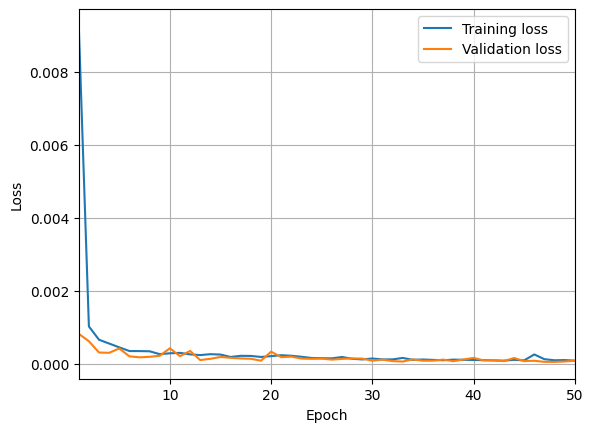

In [50]:
#Training process
file = os.path.join(BACK_UP,"epoch.json")
with open(file, "r") as f:
    epoch = json.load(f)
    train = np.array(epoch["train"])
    val = np.array(epoch["val"])
    x = np.array(range(len(train)))
    plt.plot(np.arange(1, 51),train,label="Training loss")
    plt.plot(np.arange(1, 51),val,label="Validation loss")
    plt.grid()
    plt.legend()
    plt.xlim((1,50))
    plt.ylabel("Loss")
    plt.xlabel("Epoch")
    plt.show()

C:\Users\phank\AppData\Local\Temp\ipykernel_10980\2207325470.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


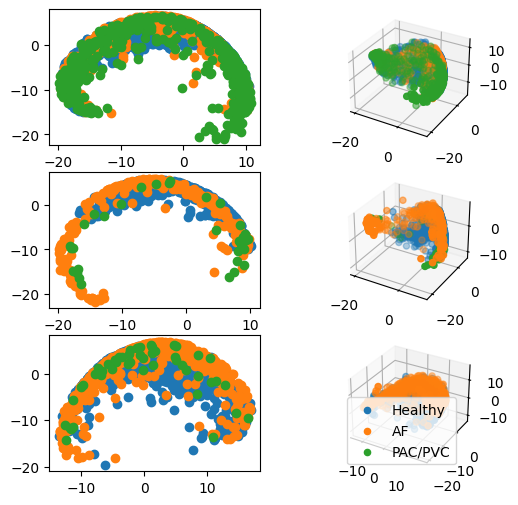

3483648


RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

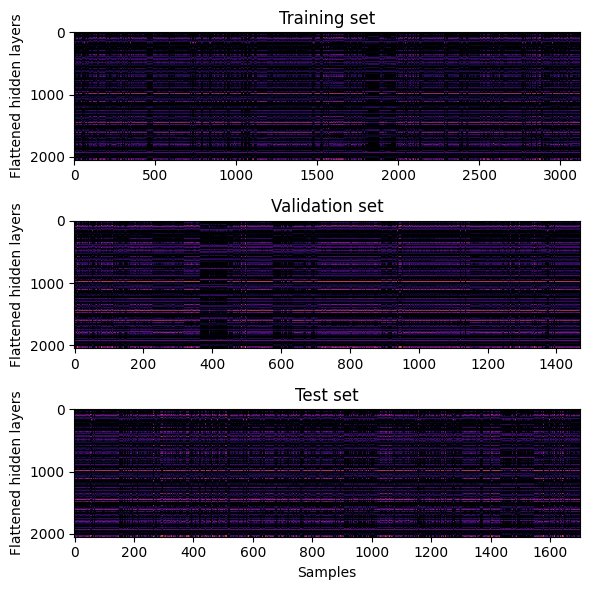

In [53]:
#PCA case
file1 = os.path.join(BACK_UP,"train_latent.json")
file2 = os.path.join(BACK_UP,"val_latent.json")
file3 = os.path.join(BACK_UP,"test_latent.json")

fig = plt.figure(figsize=(6, 6))
ax1 = fig.add_subplot(3, 2, 1)
ax2 = fig.add_subplot(3, 2, 2, projection='3d')
ax3 = fig.add_subplot(3, 2, 3)
ax4 = fig.add_subplot(3, 2, 4, projection='3d')
ax5 = fig.add_subplot(3, 2, 5)
ax6 = fig.add_subplot(3, 2, 6, projection='3d')

with open(file1, "r") as f:
    data = json.load(f)
    latent_np1 = np.array(data["latent_np"])
    latent = np.array(data["latent"])
    idx0 = np.where(np.array(data["disease"]) == 0)[0]
    idx1 = np.where(np.array(data["disease"]) == 1)[0]
    idx2 = np.where(np.array(data["disease"]) > 1)[0]
    ax1.scatter(latent[idx0, 0], latent[idx0, 1], label = "Healthy")
    ax1.scatter(latent[idx1, 0], latent[idx1, 1], label = "AF")
    ax1.scatter(latent[idx2, 0], latent[idx2, 1], label = "PAC/PVC")
    ax2.scatter(latent[idx0, 0], latent[idx0, 1], latent[idx0, 2], label = "Healthy")
    ax2.scatter(latent[idx1, 0], latent[idx1, 1], latent[idx1, 2], label = "AF")
    ax2.scatter(latent[idx2, 0], latent[idx2, 1], latent[idx2, 2], label = "PAC/PVC")
    
plt.legend()

with open(file2, "r") as f:
    data = json.load(f)
    latent_np2 = np.array(data["latent_np"])
    latent = np.array(data["latent"])
    idx0 = np.where(np.array(data["disease"]) == 0)[0]
    idx1 = np.where(np.array(data["disease"]) == 1)[0]
    idx2 = np.where(np.array(data["disease"]) > 1)[0]
    ax3.scatter(latent[idx0, 0], latent[idx0, 1], label = "Healthy")
    ax3.scatter(latent[idx1, 0], latent[idx1, 1], label = "AF")
    ax3.scatter(latent[idx2, 0], latent[idx2, 1], label = "PAC/PVC")
    ax4.scatter(latent[idx0, 0], latent[idx0, 1], latent[idx0, 2], label = "Healthy")
    ax4.scatter(latent[idx1, 0], latent[idx1, 1], latent[idx1, 2], label = "AF")
    ax4.scatter(latent[idx2, 0], latent[idx2, 1], latent[idx2, 2], label = "PAC/PVC")

with open(file3, "r") as f:
    data = json.load(f)
    latent_np3 = np.array(data["latent_np"])
    latent = np.array(data["latent"])
    idx0 = np.where(np.array(data["disease"]) == 0)[0]
    idx1 = np.where(np.array(data["disease"]) == 1)[0]
    idx2 = np.where(np.array(data["disease"]) > 1)[0]
    ax5.scatter(latent[idx0, 0], latent[idx0, 1], label = "Healthy")
    ax5.scatter(latent[idx1, 0], latent[idx1, 1], label = "AF")
    ax5.scatter(latent[idx2, 0], latent[idx2, 1], label = "PAC/PVC")
    ax6.scatter(latent[idx0, 0], latent[idx0, 1], latent[idx0, 2], label = "Healthy")
    ax6.scatter(latent[idx1, 0], latent[idx1, 1], latent[idx1, 2], label = "AF")
    ax6.scatter(latent[idx2, 0], latent[idx2, 1], latent[idx2, 2], label = "PAC/PVC")

plt.legend()
plt.show()


latent_np1 = (latent_np1 - latent_np1.min()) / (latent_np1.max() - latent_np1.min() + 1e-8)
latent_np2 = (latent_np2 - latent_np2.min()) / (latent_np2.max() - latent_np2.min() + 1e-8)
latent_np3 = (latent_np3 - latent_np3.min()) / (latent_np3.max() - latent_np3.min() + 1e-8)
sketch1 = np.transpose(latent_np1)
sketch2 = np.transpose(latent_np2)
sketch3 = np.transpose(latent_np3)
print(sketch3.size)
fig, ax = plt.subplots(3,1,figsize=(6,6))
ax[0].imshow(sketch1,aspect='auto',cmap='inferno',interpolation='nearest')
ax[0].set_ylabel("Flattened hidden layers")
ax[0].set_title("Training set")
ax[1].imshow(sketch2,aspect='auto',cmap='inferno',interpolation='nearest')
ax[1].set_ylabel("Flattened hidden layers")
ax[1].set_title("Validation set")
ax[2].imshow(sketch3[:,],aspect='auto',cmap='inferno',interpolation='nearest')
ax[2].set_xlabel("Samples")
ax[2].set_ylabel("Flattened hidden layers")
ax[2].set_title("Test set")
plt.tight_layout()
plt.colorbar()
plt.show()

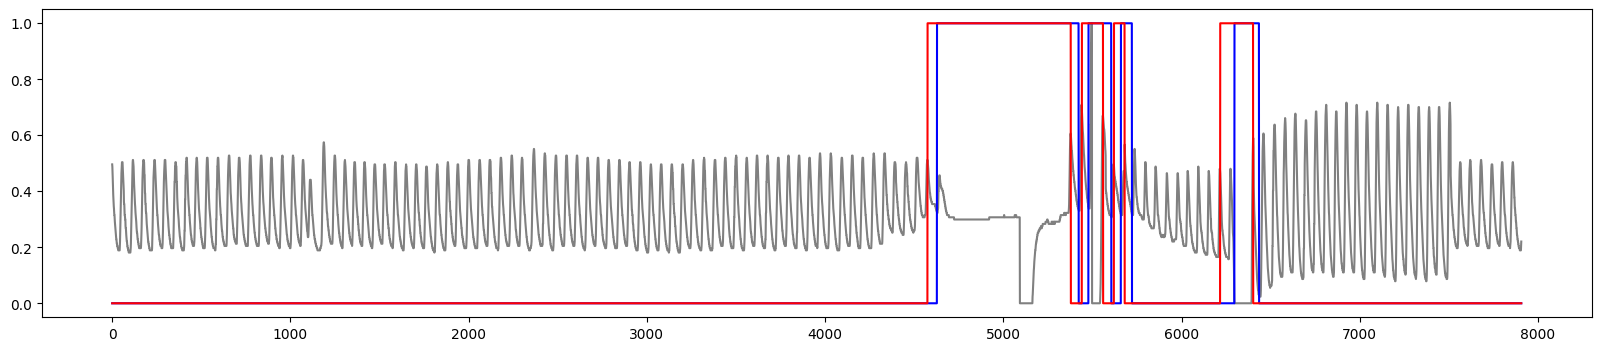

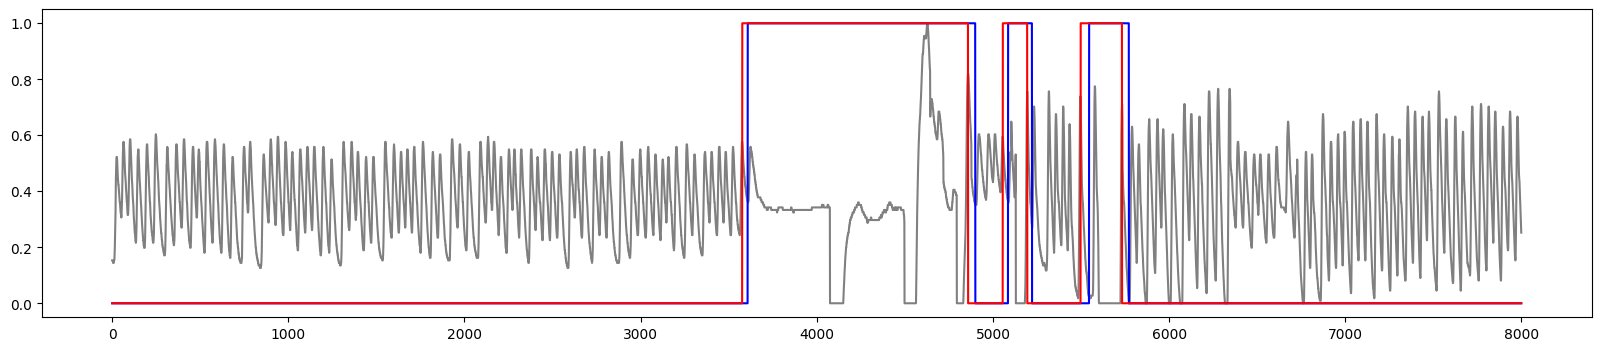

In [32]:
#Inference
file = os.path.join(BACK_UP,"depict.json")
with open(file, "r") as f:
    data = json.load(f)
    lab = data["label"]
    ppg = data["ppg"]
    adjust = data["adjust"]
    for i in [5,4]:
        plt.figure(figsize=(20, 4))
        plt.plot(ppg[i][500:8500],color = "gray",label = "Prediction")
        plt.plot(lab[i][500:8500],color = "blue",label = "Signal")
        plt.plot(adjust[i][500:8500],color = "red",label = "Signal")
